In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import ast

# Cargar datos
nuccore = pd.read_csv("nuccore.csv")
assembly = pd.read_csv("assembly.csv")
typing = pd.read_csv("typing.csv")

print("nuccore:", nuccore.shape)
print("assembly:", assembly.shape)
print("typing:", typing.shape)


nuccore: (72556, 21)
assembly: (22065, 9)
typing: (72556, 29)


In [2]:
# --------------------------------------------
# 1. Expandir la lista de NUCCORE_UID en assembly
# --------------------------------------------
assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
assembly_long = assembly.explode("NUCCORE_UID").reset_index(drop=True)

# --------------------------------------------
# 2. Unir con nuccore.csv para obtener NUCCORE_ACC
# --------------------------------------------
asm_nuccore = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC"]],
    on="NUCCORE_UID",
    how="left"
)

# --------------------------------------------
# 3. Unir con typing.csv para obtener rep_type(s)
# --------------------------------------------
typing_small = typing[["NUCCORE_ACC", "rep_type(s)"]].copy()
df = asm_nuccore.merge(typing_small, on="NUCCORE_ACC", how="left")

# --------------------------------------------
# 4. Convertir rep_type(s) en listas y expandir
# --------------------------------------------
def parse_rep(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in x.split(",")]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)

# Expandir una fila por cada replicón
df_long = df.explode("rep_types").reset_index(drop=True)

df_long.head()


,ASSEMBLY_UID,NUCCORE_UID,ASSEMBLY_ACC,ASSEMBLY_Status,ASSEMBLY_coverage,ASSEMBLY_SeqReleaseDate,ASSEMBLY_SubmissionDate,ASSEMBLY_Lastest,BIOSAMPLE_ACC,NUCCORE_ACC,rep_type(s),rep_types
0,22538391,2728196000,GCF_022163485.2,Complete Genome,1,2024-05-02,2024-05-02,True,SAMN25556619,NZ_CP091877.2,"rep_cluster_1017,rep_cluster_1017,rep_cluster_...",rep_cluster_1017
1,22538391,2728196000,GCF_022163485.2,Complete Genome,1,2024-05-02,2024-05-02,True,SAMN25556619,NZ_CP091877.2,"rep_cluster_1017,rep_cluster_1017,rep_cluster_...",rep_cluster_1017
2,22538391,2728196000,GCF_022163485.2,Complete Genome,1,2024-05-02,2024-05-02,True,SAMN25556619,NZ_CP091877.2,"rep_cluster_1017,rep_cluster_1017,rep_cluster_...",rep_cluster_1215
3,22538391,2728196000,GCF_022163485.2,Complete Genome,1,2024-05-02,2024-05-02,True,SAMN25556619,NZ_CP091877.2,"rep_cluster_1017,rep_cluster_1017,rep_cluster_...",rep_cluster_2176
4,58701828,2728132227,GCF_039519245.1,Complete Genome,1759.73,2024-05-08,2024-05-08,True,SAMN41108010,NZ_CP154371.1,rep_cluster_1118,rep_cluster_1118


In [3]:
intra_rows = []

for (assembly_acc, nuccore_acc), sub in df_long.groupby(["ASSEMBLY_ACC", "NUCCORE_ACC"]):
    
    reps = sub["rep_types"].dropna().unique()
    
    if len(reps) > 1:
        for a, b in combinations(sorted(reps), 2):
            intra_rows.append({
                "ASSEMBLY_ACC": assembly_acc,
                "NUCCORE_ACC": nuccore_acc,
                "repA": a,
                "repB": b,
                "coexistence": "same_plasmid"
            })

intra_pairs = pd.DataFrame(intra_rows)
intra_pairs.head()


,ASSEMBLY_ACC,NUCCORE_ACC,repA,repB,coexistence
0,GCA_000714635.1,CP008701.1,IncFIB,IncFII,same_plasmid
1,GCA_000714635.1,CP008701.1,IncFIB,IncR,same_plasmid
2,GCA_000714635.1,CP008701.1,IncFIB,rep_cluster_2183,same_plasmid
3,GCA_000714635.1,CP008701.1,IncFII,IncR,same_plasmid
4,GCA_000714635.1,CP008701.1,IncFII,rep_cluster_2183,same_plasmid


In [4]:
inter_rows = []

for assembly_acc, sub in df_long.groupby("ASSEMBLY_ACC"):
    
    # Todos los replicones presentes en la célula
    reps = sub["rep_types"].dropna().unique()
    
    # Todas las combinaciones posibles dentro del ensamblado
    all_pairs = set(combinations(sorted(reps), 2))
    
    # Pares dentro del mismo plásmido en esta célula
    intra_for_asm = intra_pairs[intra_pairs["ASSEMBLY_ACC"] == assembly_acc]
    intra_set = set(
        tuple(sorted([row["repA"], row["repB"]]))
        for _, row in intra_for_asm.iterrows()
    )
    
    # Pares que solo comparten célula (no plásmido)
    inter_only = all_pairs - intra_set
    
    for a, b in inter_only:
        inter_rows.append({
            "ASSEMBLY_ACC": assembly_acc,
            "repA": a,
            "repB": b,
            "coexistence": "same_cell"
        })

inter_pairs = pd.DataFrame(inter_rows)
inter_pairs.head()


,ASSEMBLY_ACC,repA,repB,coexistence
0,GCA_000487275.2,ColpVC,rep_cluster_2335,same_cell
1,GCA_000487275.2,IncN,rep_cluster_2335,same_cell
2,GCA_000487275.2,ColpVC,IncN,same_cell
3,GCA_000732525.2,rep_cluster_1738,rep_cluster_1958,same_cell
4,GCA_000732525.2,rep_cluster_1738,rep_cluster_1909,same_cell


In [5]:
# Unir intra + inter
coexistence_pairs = pd.concat([intra_pairs, inter_pairs], ignore_index=True)

print(coexistence_pairs.shape)
coexistence_pairs.head()

# Exportar
coexistence_pairs.to_csv("replicon_coexistence_pairs_alltypes.csv", index=False)


(99543, 5)


In [27]:
import pandas as pd
import numpy as np
from itertools import combinations
import ast
from scipy.stats import fisher_exact

############################################################
# 1. LOAD DATA
############################################################
nuccore   = pd.read_csv("nuccore.csv")
assembly  = pd.read_csv("assembly.csv")
typing    = pd.read_csv("typing.csv")

nuccore["genus"] = nuccore["NUCCORE_Description"].str.split().str[0]

############################################################
# 2. EXPAND ASSEMBLY → NUCCORE
############################################################
assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
assembly_long = assembly.explode("NUCCORE_UID").reset_index(drop=True)

df = assembly_long.merge(
    nuccore[["NUCCORE_UID","NUCCORE_ACC","genus"]],
    on="NUCCORE_UID", how="left"
)

df = df.merge(
    typing[["NUCCORE_ACC","rep_type(s)"]],
    on="NUCCORE_ACC", how="left"
)

def parse_rep(x):
    if pd.isna(x): return []
    return [i.strip() for i in x.split(",")]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)
df_long = df.explode("rep_types").dropna(subset=["rep_types"]).reset_index(drop=True)

############################################################
# 3. COUNT REPLICON PRESENCE BY PLASMID (NUCCORE_ACC)
############################################################
plasmid_reps = df_long[["NUCCORE_ACC","rep_types"]].drop_duplicates()

rep_plasmid_freq = (
    plasmid_reps.groupby("rep_types")
    .size().reset_index(name="n_plasmids")
)

# Filter replicons in ≥5 plasmids
rep_plasmid_freq = rep_plasmid_freq[rep_plasmid_freq["n_plasmids"] >= 5]

############################################################
# 4. COMPUTE CO-LOCALIZATION IN PLASMIDS
############################################################
pairs = []
for plasmid, sub in plasmid_reps.groupby("NUCCORE_ACC"):
    reps = sorted(sub["rep_types"].unique())
    for a, b in combinations(reps, 2):
        pairs.append((a,b))

pair_df = pd.DataFrame(pairs, columns=["repA","repB"])
pair_freq = pair_df.groupby(["repA","repB"]).size().reset_index(name="n_same_plasmid")

############################################################
# 5. MERGE WITH FREQUENCIES
############################################################
assoc = pair_freq.merge(
    rep_plasmid_freq.rename(columns={"rep_types":"repA","n_plasmids":"nA"}),
    on="repA", how="inner"
).merge(
    rep_plasmid_freq.rename(columns={"rep_types":"repB","n_plasmids":"nB"}),
    on="repB", how="inner"
)

N = df_long["NUCCORE_ACC"].nunique()

############################################################
# 6. CORRECT n_same_cell (BY CELL, NOT BY PLASMID)
############################################################
# Presence/absence matrix at CELL LEVEL
cell_reps = (
    df_long.groupby("ASSEMBLY_ACC")["rep_types"]
    .apply(lambda x: set(x.dropna()))   # <-- ENSURES each replicon counted ONCE per cell
)

cell_pairs = []
for cell, repset in cell_reps.items():
    reps = sorted(repset)
    for a, b in combinations(reps, 2):
        cell_pairs.append((a,b))

cell_freq = (
    pd.DataFrame(cell_pairs, columns=["repA","repB"])
    .groupby(["repA","repB"]).size().reset_index(name="n_same_cell")
)

assoc = assoc.merge(cell_freq, on=["repA","repB"], how="left")
assoc["n_same_cell"] = assoc["n_same_cell"].fillna(0).astype(int)

# Filter: must appear together ≥5 times in cell
assoc = assoc[assoc["n_same_cell"] >= 5]

############################################################
# 7. BUILD 2×2 TABLE AT PLASMID LEVEL + FISHER
############################################################
odds_list = []
pvals = []

for _, row in assoc.iterrows():

    a = row["n_same_plasmid"]
    b = max(row["nA"] - a, 0)
    c = max(row["nB"] - a, 0)
    d = max(N - (a + b + c), 0)

    # Haldane correction
    a += 0.5; b += 0.5; c += 0.5; d += 0.5

    OR, p = fisher_exact([[a,b],[c,d]], alternative="two-sided")

    odds_list.append(OR)
    pvals.append(p)

assoc["odds_ratio_plasmid"] = odds_list
assoc["p_value_plasmid"] = pvals

############################################################
# 8. COINTEGRATION EFFICIENCY (NOW GUARANTEED ≤1)
############################################################
assoc["cointegration_efficiency"] = assoc["n_same_plasmid"] / assoc["n_same_cell"]

############################################################
# 9. CLASSIFICATION
############################################################
def classify(row):
    if row["p_value_plasmid"] < 0.05:
        if row["odds_ratio_plasmid"] > 1:
            return "COINTEGRATION"
        elif row["odds_ratio_plasmid"] < 1:
            return "REPULSION"
    return "NEUTRAL"

assoc["category"] = assoc.apply(classify, axis=1)

############################################################
# 10. FINAL
############################################################
final_table = assoc.sort_values("p_value_plasmid")
print(final_table.head(50))


                          repA              repB  n_same_plasmid    nA    nB  \
357                    IncHI2A  rep_cluster_1088             724   727   740   
139                     IncFIA            IncFIB            1856  4185  6778   
264                     IncFIC  rep_cluster_2244             451  2153   518   
304                     IncFII  rep_cluster_2183            1281  4571  1344   
186                     IncFIB            IncFIC            1407  6778  2153   
187                     IncFIB            IncFII            2541  6778  4571   
140                     IncFIA            IncFIC            1560  4185  2153   
141                     IncFIA            IncFII            1364  4185  4571   
541           rep_cluster_1017  rep_cluster_1733             490  1143   707   
923           rep_cluster_1733  rep_cluster_2214             238   707   267   
220                     IncFIB  rep_cluster_2244             503  6778   518   
216                     IncFIB  rep_clus

In [28]:
final_table.to_csv("replicon_association_table_big_FINAL.csv", index=False)


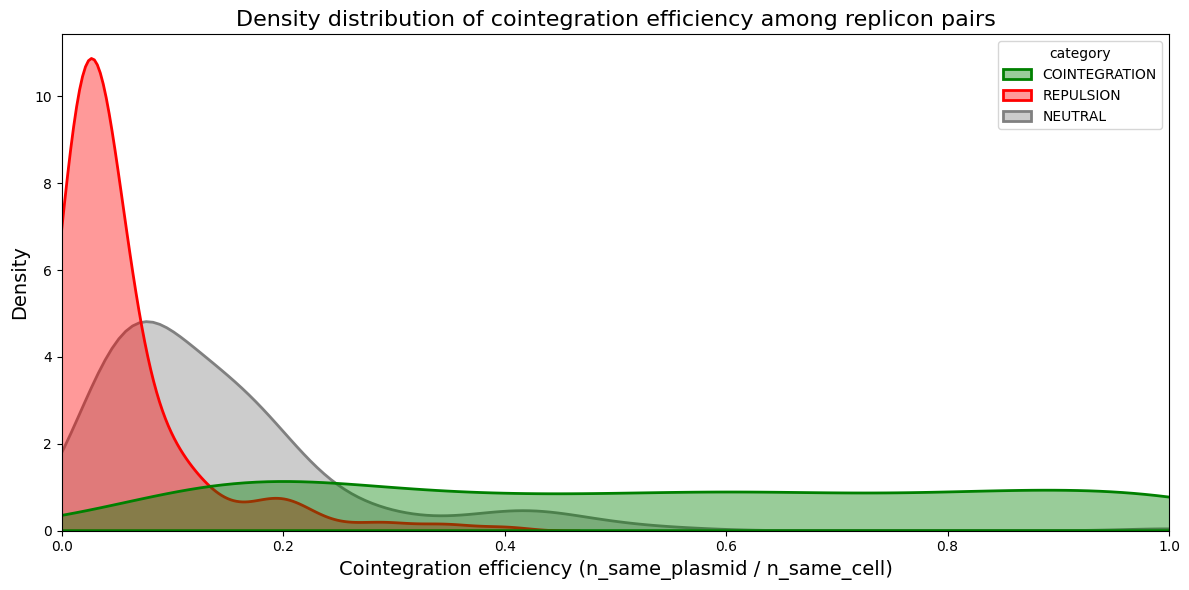

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = final_table.copy()

plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df_plot,
    x="cointegration_efficiency",
    hue="category",
    palette={"COINTEGRATION": "green", "REPULSION": "red", "NEUTRAL": "gray"},
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.xlabel("Cointegration efficiency (n_same_plasmid / n_same_cell)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Density distribution of cointegration efficiency among replicon pairs", fontsize=16)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()
